In [1]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.spatial.distance import pdist, squareform
from pathlib import Path
import prince
import dash
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince
from sklearn.model_selection import LeaveOneOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.linear_model import ElasticNet
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.patches import Ellipse
from difflib import get_close_matches
from sklearn.impute import KNNImputer
import plotly.graph_objects as go
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from scipy.cluster.hierarchy import linkage, dendrogram
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
import plotly.express as px
from sklearn.neighbors import NearestNeighbors



# Data Aggregation: Combining Sample and Control Compound Files

In [2]:
import os
import glob
import yaml
import importlib
import compound_analysis_module2 as cam
import importlib
importlib.reload(cam)
# -----------------------------
# Load config
# -----------------------------
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\config.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths = config.get("data_paths", config.get("paths", {}))

# -----------------------------
# Read paths from config
# -----------------------------
sample_files = paths.get("sample_files", [])
base_compound_dir = paths.get("base_compound_dir", "")
output_path = paths.get("output_path", "")

blank_files = paths.get("blank_files", [])
env_files = paths.get("env_files", [])


# fallback: auto-detect blanks (procedural + env)
if not blank_files:
    blank_files = glob.glob(
        os.path.join(base_compound_dir, "day_*", "*blank*.csv")
    ) + glob.glob(
        os.path.join(base_compound_dir, "day_*", "*env*.csv")
    )

# -----------------------------
# Sanity checks
# -----------------------------
print(f"Samples listed manually: {len(sample_files)}")
print(f"Blank files found: {len(blank_files)}")

print("\nBlank files used:")
for bf in blank_files:
    print("  -", bf)

# -----------------------------
# Run compound combination + blank filtering
# -----------------------------
combined_df = cam.combine_compound_data(
    sample_files=sample_files,
    env_files=env_files,
    blank_files=blank_files,
    output_path=output_path
)



Samples listed manually: 94
Blank files found: 1

Blank files used:
  - C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/analysis with mz/monfared_compound_2024/blank.csv

Combined file saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/combined.csv

FileType counts (raw, before filtering):
FileType
sample    18334
env          22
blank        12
Name: count, dtype: int64

Preview of combined data:
   Component RT                  Compound Name  Match Factor  Best Hit  \
0      1.999217                        Propene     65.242228      True   
1      2.177691        2-Propanone, 1-methoxy-     87.899550      True   
2      2.359333            Propanal, 2-methyl-     78.339167      True   
3      2.465450  l-2-Amino-4-methyl-1-pentanol     68.259874      True   
4      2.504033        Undecane, 2,2-dimethyl-     68.175810      True   

   Formula  Base Peak MZ FileType   FileName  RI  
0     C3H6     40.959613   sample  ADORA.csv NaN  


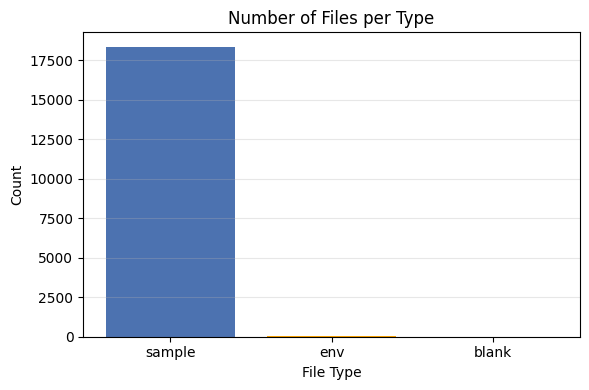

 File type count plot generated successfully.
FileType
sample    18334
env          22
blank        12
Name: count, dtype: int64


In [3]:
import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)

from compound_analysis_module import plot_filetype_counts

# Example usage
plot_filetype_counts(combined_df)


In [4]:
pip install fuzzywuzzy[speedup]


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Contamination filtering

Sample compounds before filtering: 18334
Sample compounds after filtering: 16602
Removed 1732 sample peaks (ΔRT ≤ 0.4)


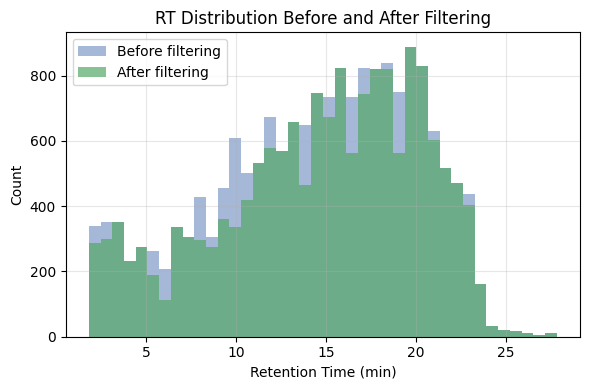

✅ RT distribution plot generated successfully.


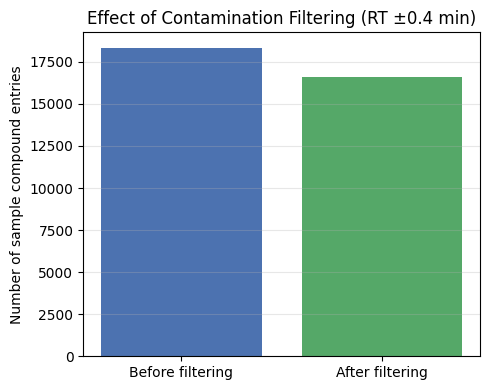

 Filtering effect plot generated successfully. (Before: 18334, After: 16602)


In [5]:
import importlib
import compound_analysis_module as cam
importlib.reload(cam)

real_compounds = cam.filter_real_compounds(combined_df, rt_tolerance=0.4)

cam.plot_rt_distribution(combined_df, real_compounds)
cam.plot_filtering_effect(combined_df, real_compounds, rt_tolerance=0.4)


# Matching NIST-Identified Compounds with GC–MS Peak Intensities

In [6]:

# Read the config file for gc mass data
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Access the path from config
csv_path = config["paths"]["samples_filtered"]

# Load the data
samples_filtered = pd.read_csv(csv_path)

print(samples_filtered.head())


       Sample  Peak  tR_best  m/z Variety  Intensity_corrected    QC4_median  \
0  AllSamples     1    1.906   40   ADORA         20207.269272  3.105743e+07   
1  AllSamples     2    1.955   44   ADORA        200279.729363  3.105743e+07   
2  AllSamples     3    1.987   37   ADORA         97223.774931  3.105743e+07   
3  AllSamples     4    2.012   64   ADORA        956850.569770  3.105743e+07   
4  AllSamples     5    2.043   41   ADORA        769640.970650  3.105743e+07   

   Ratio_normalized  Log10_normalized  
0          0.000651          0.000282  
1          0.006449          0.002792  
2          0.003130          0.001357  
3          0.030809          0.013178  
4          0.024781          0.010631  


# Checking the presence of known potato aroma compounds

In [ ]:
import os, re, glob, yaml, importlib
import numpy as np
import pandas as pd
from difflib import get_close_matches
from collections import OrderedDict, defaultdict
import compound_analysis_module as cam
importlib.reload(cam)



# =========================================================
# 2) Output directory
# =========================================================
aroma_output_path = paths.get("aroma_output", paths.get("aroma_output_path", "aroma_output.csv"))
out_dir = os.path.dirname(aroma_output_path) if os.path.dirname(aroma_output_path) else "."
os.makedirs(out_dir, exist_ok=True)

# =========================================================
# 3) Potato aroma list (core)
# =========================================================
POTATO_AROMAS_CORE = [
    "Hexanal","Heptanal","Octanal","Nonanal","Decanal",
    "Pentanal","Propanal",
    "2-Methylbutanal","3-Methylbutanal","Butanal, 3-methyl-",
    "4-Heptenal","2-Pentenal","2-Hexenal","2-Octenal","2-Nonenal","2-Heptenal",
    "2-Trans-nonenal","2-Trans-octenal",
    "2,4-Heptadienal","2,4-Octadienal",
    "(E, E)-2,4-Nonadienal","(E, Z)-2,4-Decadienal","(E, E)-2,4-Decadienal","2,4-Nonadienal",
    "Benzaldehyde","2-methyl-Benzaldehyde","4-methyl-Benzaldehyde",
    "Benzeneacetaldehyde","Phenylacetaldehyde",

    "1-Heptanol","1-Nonanol","1-Octen-3-ol","1-Pentanol","3-Nonen-1-ol",
    "Hexanol","Phenylethyl alcohol","1-Phenylethanol",
    "2-Methyl-1-propanol","3-Methyl-1-butanol","Ethanol","Benzyl alcohol",

    "2-Heptanone","2-Nonanone","3-Heptanone","3-Octanone","3-Octen-2-one","1-Penten-3-one",
    "2,3-Butanedione","2,3-Pentanedione","Acetophenone","4-Methyl-2-pentanone",
    "(E, E)-3,5-Octadien-2-one","3,5-Octadien-2-one",

    "Acetic acid","Butanoic acid","Hexanoic acid","Isobutyric acid","Isovaleric acid",
    "Propanoic acid","Octanoic acid","2-Octenoic acid","Decanoic acid","nonanoic acid",

    "Methanethiol","Methional",
    "Dimethyl sulfide","Dimethyl disulfide","Dimethyl trisulfide","Dimethyl tetrasulfide",
    "Carbon disulfide","Hydrogen sulfide",
    "2-Methyl-3-furanthiol","3-Methylthiopropanal","3-(Methylthio)propanal",
    "2-Acetylthiazole","2-Methyl-3-thiazoline","2-Methylthiazole","Allyl methyl sulfide",

    "Ethyl acetate","Isoamyl acetate","Ethyl butanoate","Ethyl hexanoate","Methyl butanoate",
    "Ethyl 2-methylbutanoate","Ethyl propanoate","Methyl propanoate","Ethyl pentanoate",

    "2-Acetylpyrazine","2-Ethyl-3,5-dimethylpyrazine",
    "2-Isobutyl-3-methoxypyrazine","2-Isopropyl-3-methoxypyrazine",
    "2-Ethyl-3-methylpyrazine","Trimethylpyrazine","Tetramethylpyrazine",
    "2,5-Dimethylpyrazine","2,6-Dimethylpyrazine","2-Methylpyrazine",

    "Furfural","5-Methylfurfural","3-Furaldehyde",
    "methyl-Cyclopentane","n-Hexane",
    "2-n-Butyl furan","cis-2-(2-Pentenyl) furan",
    "2-pentyl-Furan","Furan, 2-pentyl-","2-Pentylfuran","2-(2-propenyl)-Furan",
    "1,2-dimethoxy-Benzene","2-methoxy-Phenol","Methyl salicylate","Mequinol",

    "Copaene","trans-beta-Ionone","Linalool","alpha-Terpineol",".alpha.-Terpineol",
    "Dimethyl phthalate",
    "Undecanal","Dodecanal",
    "(E)-2-Hexenal","(E)-2-Heptenal","(E)-2-Decenal",
    "2-Octenal, (E)-","2-Nonenal, (E)-",
    "2(3H)-Furanone, dihydro-5-pentyl-",
]

POTATO_AROMAS_OPTIONAL = [
    "Phenol",
    "Benzoic acid",
    "Benzoic acid, methyl ester",

    "Eucalyptol",
    "Limonene",
    "3-Carene",

    "Tridecanal",
    "Tetradecanal",
    "2-Undecenal",
    "2-Tridecenal",

    "6-Methyl-5-hepten-2-one",
    "2-Methylpropanal",
    "1-Octyn-3-ol",
    "3-Methylfuran",
    "2-Ethylfuran",
    "2-Acetyl-5-methylfuran",

    "Acetic acid, ethenyl ester",
    "Acetic acid, methyl ester",
    "Butanoic acid, butyl ester",
    "Hexanoic acid, methyl ester",
    "Octanoic acid, methyl ester",
    "Dodecanoic acid",
    "Dodecanoic acid, 1-methylethyl ester",

    "1-Hexanol, 2-ethyl-",
    "Styrene",
    "n-Hexadecanoic acid",
    "Ethanol, 2-phenoxy-",
    "Tridecane",
    "Tetradecane",
    "Hexadecane",
    "2-Propanone, 1-methoxy-",
    "2-Decanone",
    "3-Heptanone, 4-methyl-",
    "Methyl 8-oxooctanoate",
    "Nonanoic acid, 9-oxo-, methyl ester",
]

potato_aromas = list(OrderedDict.fromkeys(POTATO_AROMAS_CORE + POTATO_AROMAS_OPTIONAL))

# =========================================================
# 4) Helpers: normalize + alias + collision-safe canonical mapping
# =========================================================
def strip_stereo(s: str) -> str:
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\(\s*[EeZz]\s*,\s*[EeZz]\s*\)", "", s)
    s = re.sub(r"\(\s*[EeZz]\s*\)", "", s)
    s = re.sub(r"\b(cis|trans)\b\s*-?", "", s, flags=re.IGNORECASE)
    return s

def normalize(s: str) -> str:
    s = strip_stereo(s).lower().strip()
    return re.sub(r"[^a-z0-9]+", "", s)

ALIASES = {
    "Phenylacetaldehyde": ["benzeneacetaldehyde"],
    "Phenylethyl alcohol": ["2phenylethanol", "phenethyl alcohol", "phenylethanol", "2-phenylethanol"],
    "alpha-Terpineol": [".alpha.-terpineol", "alphaterpineol", "alpha terpineol"],
    "Furan, 2-pentyl-": ["2pentylfuran", "2-pentylfuran", "2-pentyl furan", "furan, 2-pentyl"],

    "Dimethyl disulfide": ["disulfide, dimethyl"],
    "Dimethyl sulfide": ["sulfide, dimethyl"],
    "Dimethyl trisulfide": ["trisulfide, dimethyl"],

    "Butanal, 3-methyl-": ["3-methylbutanal", "butanal,3-methyl-", "3-methyl butanal"],
    "2-Octenal, (E)-": ["(e)-2-octenal", "2-octenal (e)", "2-octenal, (e)-"],
    "2-Nonenal, (E)-": ["(e)-2-nonenal", "2-nonenal (e)", "2-nonenal, (e)-"],

    # useful extra
    "2-Methylbutanal": ["butanal, 2-methyl-", "2-methyl butanal", "2-methylbutyraldehyde"],
    "3-Methylbutanal": ["butanal, 3-methyl-", "isovaleraldehyde", "3-methyl butanal"],

    "6-Methyl-5-hepten-2-one": ["5-hepten-2-one, 6-methyl-", "sulcatone"],
    "2-Methylpropanal": ["propanal, 2-methyl-", "isobutyraldehyde"],

    "2-Undecenal": ["(e)-2-undecenal", "2-undecenal (e)", "2-undecenal, (e)-"],
    "2-Tridecenal": ["(e)-2-tridecenal", "2-tridecenal (e)", "2-tridecenal, (e)-"],

    "3-Methylfuran": ["furan, 3-methyl-"],
    "2-Ethylfuran": ["furan, 2-ethyl-"],

    "Acetic acid, ethenyl ester": ["vinyl acetate"],
    "Acetic acid, methyl ester": ["methyl acetate"],
    "Butanoic acid, butyl ester": ["butyl butanoate"],
    "Hexanoic acid, methyl ester": ["methyl hexanoate"],
    "Octanoic acid, methyl ester": ["methyl octanoate"],
    "Dodecanoic acid, 1-methylethyl ester": ["isopropyl dodecanoate"],

    "1-Hexanol, 2-ethyl-": ["2-ethyl-1-hexanol", "2-ethylhexanol"],
    "n-Hexadecanoic acid": ["palmitic acid", "hexadecanoic acid"],
    "Ethanol, 2-phenoxy-": ["phenoxyethanol", "2-phenoxyethanol"],

    "Benzoic acid, methyl ester": ["methyl benzoate"],
    "Eucalyptol": ["1,8-cineole", "cineole"],
    "Limonene": ["d-limonene", "dl-limonene"],
    "3-Carene": ["delta-3-carene", "δ-3-carene"],

    "2-Propanone, 1-methoxy-": ["1-methoxy-2-propanone", "propylene glycol monomethyl ether"],
}

# collision-safe: norm -> list of original names
by_norm = defaultdict(list)
for x in potato_aromas:
    by_norm[normalize(x)].append(x)

def pick_canonical(names):
    prefs = ["(E, E)", "(E, Z)", "(E)-", "alpha-", ".alpha.-", ", (E)-"]
    for p in prefs:
        for n in names:
            if p in n:
                return n
    return sorted(names, key=lambda s: (len(s), s))[0]

canon_norm = {k: pick_canonical(v) for k, v in by_norm.items()}

# map all variants -> chosen canonical
syn_to_canon = {}
for norm_key, names in by_norm.items():
    canon = canon_norm[norm_key]
    for n in names:
        syn_to_canon[normalize(n)] = canon

# add aliases -> canonical
for canon, alts in ALIASES.items():
    for a in alts:
        syn_to_canon[normalize(a)] = canon

canon_keys = list(canon_norm.keys())

def map_to_canonical(name: str, cutoff: float = 0.86):
    n = normalize(name)
    if n in syn_to_canon:
        return syn_to_canon[n], "exact/alias"

    for ck in canon_keys:
        if len(ck) >= 6 and ck in n:
            return canon_norm[ck], "substring"

    hit = get_close_matches(n, canon_keys, n=1, cutoff=cutoff)
    if hit:
        return canon_norm[hit[0]], "fuzzy"
    return None, "no"

# =========================================================
# 5) Load peaks (samples_filtered.csv)
# =========================================================
samples_filtered_path = paths.get(
    "samples_filtered",
    r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/samples_filtered.csv"
)

peaks = pd.read_csv(samples_filtered_path, sep=None, engine="python").copy()

if "Variety" not in peaks.columns:
    raise KeyError("samples_filtered.csv must contain a 'Variety' column.")

int_candidates = ["Intensity_corrected"]
INT_COL = next((c for c in int_candidates if c in peaks.columns), None)
if INT_COL is None:
    raise KeyError(f"No intensity column found. Tried: {int_candidates}")

rt_col = "tR_best" if "tR_best" in peaks.columns else None
if rt_col is None:
    raise KeyError("samples_filtered.csv must contain 'tR_best'")

mz_col = "m/z" if "m/z" in peaks.columns else ("mz" if "mz" in peaks.columns else None)
if mz_col is None:
    raise KeyError("samples_filtered.csv must contain 'm/z' or 'mz'")

peaks[rt_col] = pd.to_numeric(peaks[rt_col], errors="coerce")
peaks[mz_col] = pd.to_numeric(peaks[mz_col], errors="coerce")
peaks[INT_COL] = pd.to_numeric(peaks[INT_COL], errors="coerce")
peaks = peaks.dropna(subset=["Variety", rt_col, mz_col, INT_COL]).copy()
peaks["_mz_round"] = peaks[mz_col].round(0)

print("Peaks loaded:", peaks.shape, "| unique varieties:", peaks["Variety"].nunique())

# =========================================================
# 6) Prepare compound reference (RT/MZ) from compound_df
# =========================================================
compound_rt_col = next((c for c in ["Component RT"]
                        if c in combined_df.columns), None)
compound_mz_col = next((c for c in ["Base Peak MZ"]
                        if c in combined_df.columns), None)
name_col = next((c for c in ["Compound Name","Best Hit"]
                 if c in combined_df.columns), None)

if compound_rt_col is None or compound_mz_col is None or name_col is None:
    raise KeyError(
        f"compound_df must contain Name + RT + MZ columns.\n"
        f"Detected name={name_col}, rt={compound_rt_col}, mz={compound_mz_col}\n"
        f"Available columns: {combined_df.columns.tolist()}"
    )

cdf = combined_df.copy()
cdf[name_col] = cdf[name_col].astype(str)
cdf[compound_rt_col] = pd.to_numeric(cdf[compound_rt_col], errors="coerce")
cdf[compound_mz_col] = pd.to_numeric(cdf[compound_mz_col], errors="coerce")
cdf = cdf.dropna(subset=[name_col, compound_rt_col, compound_mz_col]).copy()

# map names to canonical aroma
cdf["Compound Name"], cdf["_match_type"] = zip(*cdf[name_col].map(map_to_canonical))
cdf = cdf[cdf["Compound Name"].notna()].copy()

ref = (cdf.groupby("Compound Name", as_index=False)
         .agg(rt_ref=(compound_rt_col, "median"),
              mz_ref=(compound_mz_col, "median"),
              n_hits=("Compound Name", "size")))

ref_path = os.path.join(out_dir, "aroma_reference_rt_mz.csv")
ref.to_csv(ref_path, index=False)

print("Reference aromas found:", ref["Compound Name"].nunique(), "/", len(potato_aromas))
print("Saved reference:", ref_path)

# Debug: what is missing from reference
missing_list = [x for x in potato_aromas if normalize(x) not in set(ref["Compound Name"].map(normalize))]
missing_df = pd.DataFrame({"Compound Name": missing_list})
missing_ref_path = os.path.join(out_dir, "missing_aromas_from_reference.csv")
missing_df.to_csv(missing_ref_path, index=False)
print("Missing from reference:", len(missing_list), "->", missing_ref_path)

#  dump unmapped names for alias debugging
unmapped = cdf[cdf["_match_type"].eq("no")] if "_match_type" in cdf.columns else pd.DataFrame()
unmapped_path = os.path.join(out_dir, "compound_df_unmapped_names.csv")
if not unmapped.empty:
    unmapped[[name_col]].drop_duplicates().to_csv(unmapped_path, index=False)
    print("Saved unmapped compound_df names:", unmapped_path)

# =========================================================
# 7) Match per variety (RT+MZ strict) 
# =========================================================
rt_tol = float(paths.get("rt_tol", 0.4))
mz_tol = float(paths.get("mz_tol", 0.5))

rows = []

for variety, pv in peaks.groupby("Variety", sort=False):
    pv = pv.copy()

    for _, r in ref.iterrows():
        cname = r["Compound Name"]
        rt_ref = float(r["rt_ref"])
        mz_ref = float(r["mz_ref"])
        mz_round_ref = round(mz_ref)

        # prefilter by rounded m/z
        cand = pv[np.abs(pv["_mz_round"] - mz_round_ref) <= 1].copy()
        if cand.empty:
            continue

        cand["_rt_diff"] = (cand[rt_col] - rt_ref).abs()
        cand["_mz_diff"] = (cand[mz_col] - mz_ref).abs()

        # STRICT ONLY
        strict = cand[
            (cand["_rt_diff"] <= rt_tol) &
            (cand["_mz_diff"] <= mz_tol)
        ].copy()

        if strict.empty:
            continue  #  DO NOTHING → NO FAKE TRAIT

        strict["_score"] = (
            strict["_rt_diff"] / max(rt_tol, 1e-9) +
            strict["_mz_diff"] / max(mz_tol, 1e-9)
        )

        best = strict.sort_values("_score").iloc[0]

        rows.append({
            "Variety": variety,
            "Compound Name": cname,
            "tR_best": float(best[rt_col]),
            "m/z": float(best[mz_col]),
            "peak_Intensity": float(best[INT_COL]),
            "_rt_diff": float(best["_rt_diff"]),
            "_mz_diff": float(best["_mz_diff"]),
        })
matched_per_variety = pd.DataFrame(rows)

matched_out = os.path.join(out_dir, "matched_per_variety_STRICT_ONLY.csv")
matched_per_variety.to_csv(matched_out, index=False)

print("matched_per_variety shape:", matched_per_variety.shape)
print("unique varieties:", matched_per_variety["Variety"].nunique())
print("unique aromas:", matched_per_variety["Compound Name"].nunique())
print("Saved:", matched_out)




Peaks loaded: (58844, 10) | unique varieties: 94
Reference aromas found: 97 / 161
Saved reference: .\aroma_reference_rt_mz.csv
Missing from reference: 54 -> .\missing_aromas_from_reference.csv
matched_per_variety shape: (6298, 7)
unique varieties: 94
unique aromas: 67
Saved: .\matched_per_variety_STRICT_ONLY.csv
matched_per_variety shape: (6298, 7)
unique varieties: 94
unique aromas: 67
Saved: .\matched_per_variety_STRICT_ONLY.csv


In [11]:
# import pandas as pd
# import re
# from difflib import get_close_matches

# # 1) بخون و ببین چه ستون‌هایی دارد
# miss_df = pd.read_csv(r".\missing_aromas_from_reference.csv")
# print("missing cols:", miss_df.columns.tolist())
# print(miss_df.head())

# # 2) ستون مناسب را اتوماتیک انتخاب کن
# miss_col = next(
#     (c for c in miss_df.columns if re.search(r"compound|name|aroma", str(c), re.I)),
#     miss_df.columns[0]   # اگر هیچ match نبود، ستون اول
# )

# missing = miss_df[miss_col].dropna().astype(str).tolist()
# print("missing count:", len(missing), "example:", missing[:10])


# Adding Sensory Descriptions to Identified Aroma Compounds

In [12]:
import importlib
import yaml
# import compound_analysis_module as cam

# aroma_sample_df= pd.read_csv("matched_per_variety_WITH_MZ_RT.csv")

# # importlib.reload(cam)

# # --- Load config ---
# def load_config(path="config.yaml"):
#     with open(path, "r", encoding="utf-8") as f:
#         return yaml.safe_load(f)

# config = load_config()

# # --- Output path ---
# aroma_with_descriptions_output = config["paths"]["aroma_with_descriptions_output"]

# # --- Add descriptions ---
# aroma_sample_df = cam.add_aroma_descriptions(aroma_sample_df)

# --- Save ---
# aroma_sample_df.to_csv(aroma_with_descriptions_output, index=False)
# print(f"Aroma compounds with descriptions saved to:\n{aroma_with_descriptions_output}")


# Classification of Aroma Compounds by Chemical Family

In [13]:
# import importlib
# import compound_analysis_module
# importlib.reload(compound_analysis_module)

# from compound_analysis_module import assign_aroma_descriptions_and_families

# print(assign_aroma_descriptions_and_families)

# aroma_sample_df, AROMA_DESCRIPTIONS, CHEMICAL_FAMILY_MAP = assign_aroma_descriptions_and_families(aroma_sample_df)
# import json


# with open("aroma_descriptions.json", "w", encoding="utf-8") as f:
#     json.dump(AROMA_DESCRIPTIONS, f, ensure_ascii=False, indent=2)

# with open("chemical_family_map.json", "w", encoding="utf-8") as f:
#     json.dump(CHEMICAL_FAMILY_MAP, f, ensure_ascii=False, indent=2)

# # use the function directly from the module
# aroma_sample_df, AROMA_DESCRIPTIONS, CHEMICAL_FAMILY_MAP = assign_aroma_descriptions_and_families(aroma_sample_df)
# aroma_sample_df

In [14]:
# import importlib
# import compound_analysis_module
# importlib.reload(compound_analysis_module)

# from compound_analysis_module import plot_aroma_family_distribution
# importlib.reload(compound_analysis_module)
# plot_aroma_family_distribution(aroma_sample_df)


In [22]:

import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)

from compound_analysis_module import plot_aroma_filtering_funnel

# Run the function
unique_aroma_df = plot_aroma_filtering_funnel(paroma_matrix)


KeyError: "'Compound Name' not found. Available: ['Variety', '(E)-2-Decenal', '(E)-2-Heptenal', '(E, E)-2,4-Decadienal', '(E, E)-3,5-Octadien-2-one', '1-Heptanol', '1-Hexanol, 2-ethyl-', '1-Nonanol', '1-Octen-3-ol', '1-Octyn-3-ol', '1-Penten-3-one', '1-Phenylethanol', '2(3H)-Furanone, dihydro-5-pentyl-', '2,3-Butanedione', '2-Decanone', '2-Ethylfuran', '2-Heptanone', '2-Methylbutanal', '2-Methylpropanal', '2-Nonanone', '2-Nonenal, (E)-', '2-Octenal, (E)-', '2-Propanone, 1-methoxy-', '2-Tridecenal', '3-Carene', '3-Furaldehyde', '3-Heptanone', '3-Methylbutanal', '6-Methyl-5-hepten-2-one', 'Acetic acid, ethenyl ester', 'Acetic acid, methyl ester', 'Benzaldehyde', 'Benzoic acid', 'Benzoic acid, methyl ester', 'Benzyl alcohol', 'Butanal, 3-methyl-', 'Butanoic acid', 'Decanal', 'Dimethyl disulfide', 'Dimethyl phthalate', 'Dimethyl sulfide', 'Dimethyl trisulfide', 'Dodecanal', 'Ethanol', 'Ethanol, 2-phenoxy-', 'Ethyl butanoate', 'Furan, 2-pentyl-', 'Furfural', 'Heptanal', 'Hexanal', 'Hexanoic

In [ ]:

import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_and_visualize_aroma_compounds

summary_df = summarize_and_visualize_aroma_compounds(
    aroma_sample_df=mat_gwas,
    aroma_json_path="aroma_descriptions.json",
    family_json_path="chemical_family_map.json",
    output_path=r"C:\Users\fatemehm\Documents\aroma_summary_all_47.xlsx"
)

ImportError: cannot import name 'summarize_and_visualize_aroma_compounds' from 'compound_analysis_module' (c:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\compound_analysis_module.py)

# Creating the Aroma Compound Intensity Matrix

In [ ]:
# import importlib
# import yaml
# import compound_analysis_module
# from compound_analysis_module import create_aroma_intensity_matrix

# # --- Reload your module (useful inside notebooks) ---
# importlib.reload(compound_analysis_module)

# # --- Load paths from config.yaml ---
# def load_config(path="config.yaml"):
#     with open(path, "r") as f:
#         return yaml.safe_load(f)

# config = load_config()

# # --- Get aroma matrix output path from config ---
# aroma_matrix_output_path = config["paths"]["aroma_matrix_output"]

# # --- Create intensity matrix ---
# aroma_matrix = create_aroma_intensity_matrix(aroma_sample_df)

# # --- Save using path from config ---
# aroma_matrix.to_csv(aroma_matrix_output_path, index=False)
# print(f" Aroma intensity matrix saved to:\n{aroma_matrix_output_path}")



,(E)-2-Decenal,(E)-2-Heptenal,(E)-2-Hexenal,"(E, E)-2,4-Decadienal","1,2-dimethoxy-Benzene",1-Heptanol,"1-Hexanol, 2-ethyl-",1-Nonanol,1-Octen-3-ol,1-Octyn-3-ol,...,Styrene,Tetradecanal,Tetradecane,Tridecanal,Tridecane,Undecanal,alpha-Terpineol,n-Hexadecanoic acid,n-Hexane,nonanoic acid
Variety,,,,,,,,,,,,,,,,,,,,,
ADORA,158950.924928,137333.382895,23029.325439,1.282930e+05,2.653259e+05,1.228645e+05,1.282840e+06,74974.316997,111570.271948,334920.946874,...,1.129688e+06,61124.826851,2.913931e+06,1.058447e+06,1.335313e+06,1.630551e+06,125124.868007,3.194588e+06,90534.493759,4.447489e+05
AGRIA,75482.858841,73198.432709,10921.114662,5.669891e+04,2.920500e+05,7.616342e+04,6.200850e+05,62564.190846,37125.062178,154743.668987,...,5.722605e+05,37714.348831,1.906090e+06,4.091731e+05,5.698808e+05,6.319004e+05,76561.128036,1.238362e+06,71947.138923,1.923397e+05
ALOUETTE,186391.622134,100301.606581,16871.154535,1.108280e+05,4.036373e+05,8.563213e+04,1.458943e+06,66765.428541,72220.969146,336051.875727,...,4.717749e+05,73856.427679,1.599592e+06,8.939689e+05,4.168855e+05,9.109258e+05,91806.349888,1.318677e+06,110775.863388,5.717249e+05
ALTHEA,281046.605738,182113.651794,62287.351499,1.219229e+06,5.979402e+06,3.571423e+05,4.200853e+06,351158.176386,184865.996604,311758.220008,...,1.748553e+06,351196.793469,1.074566e+07,4.554749e+06,1.303078e+06,3.185995e+06,385023.853431,2.941198e+06,109598.794643,2.299965e+06
ALTURAS,155614.308671,164142.665721,39880.416111,1.801161e+05,8.827619e+05,1.139214e+06,2.952752e+06,116091.479758,100560.391188,236419.300608,...,1.584900e+06,32000.023619,2.454429e+06,9.357897e+05,1.465886e+06,1.524989e+06,103562.994755,2.884708e+06,65127.963927,4.490274e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TETON RUSSET,131861.292111,101496.730066,20044.275091,1.155132e+05,4.180831e+05,9.801818e+04,1.461437e+06,88066.009584,63063.203799,229523.392967,...,1.042565e+06,56857.388443,2.116594e+06,7.752384e+05,3.324725e+05,9.845932e+05,94975.959800,1.217210e+06,47441.340009,6.041713e+05
TRIPLE7,82737.855200,47209.637512,7684.802516,6.454770e+04,2.612125e+05,4.952616e+04,2.054745e+05,49991.070514,28419.166851,164543.380645,...,2.074991e+05,41031.405786,1.350161e+06,6.909644e+05,2.750259e+05,5.672664e+05,109153.444390,5.676972e+05,109332.988749,3.429859e+05
VAN GOGH,111991.047694,101173.249307,32914.295592,1.112934e+05,7.018479e+05,1.332139e+05,1.412940e+06,102323.737462,92897.658617,226390.394055,...,1.306776e+06,56257.068337,5.724713e+06,4.959893e+05,1.376918e+06,1.025703e+06,148523.811055,1.646577e+06,22956.103438,4.592078e+05


# Run PCA and clustering 

Explained variance (2 PCs): 59.23%
Optimal number of clusters (based on silhouette): 2


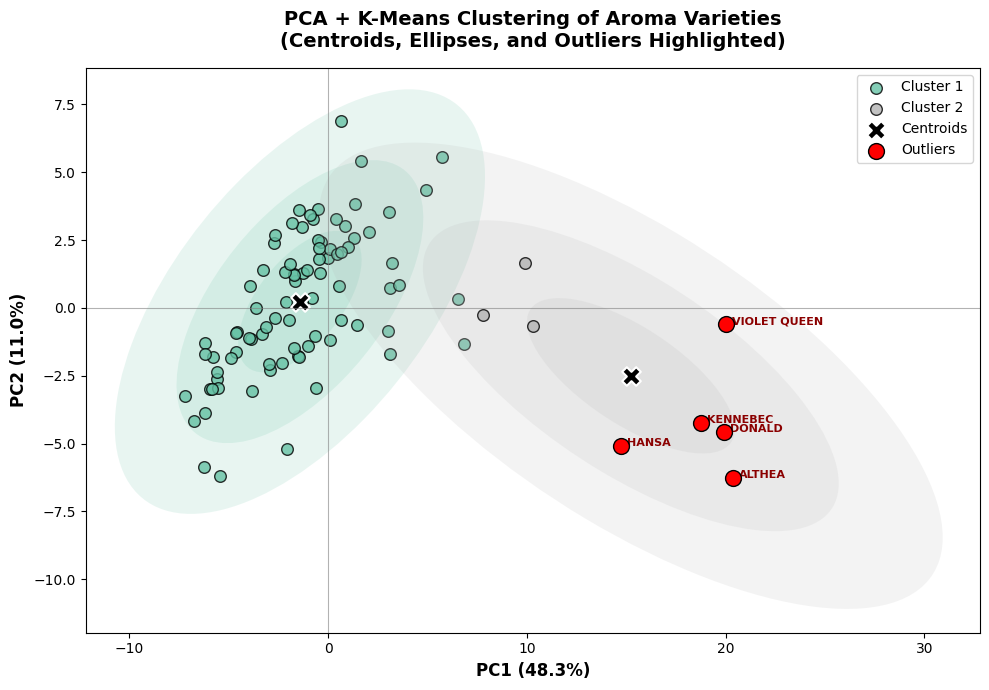


Results saved in: aroma_pca_kmeans


In [24]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import pca_kmeans_aroma


results, X_pca, clusters = pca_kmeans_aroma(paroma_matrix)


Optimal PCA components: 13 (explains 90.1% variance)


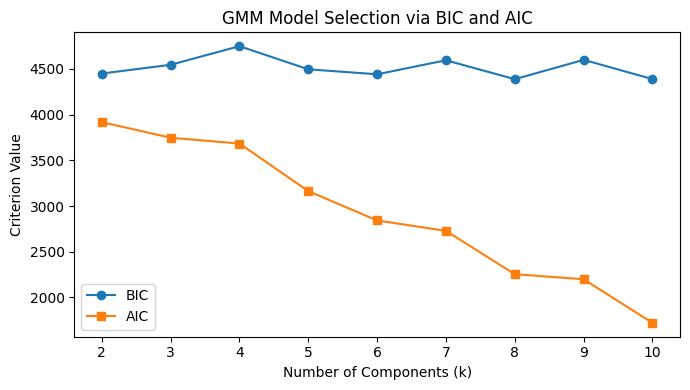

Best number of clusters (based on BIC): 8

Clustering metrics for k=8:
 Silhouette Score:       0.151
 Davies–Bouldin Index:   1.712
 Calinski–Harabasz:      24.0

Outliers detected (3): ['ALTURAS', 'DONALD', 'VIOLET QUEEN']


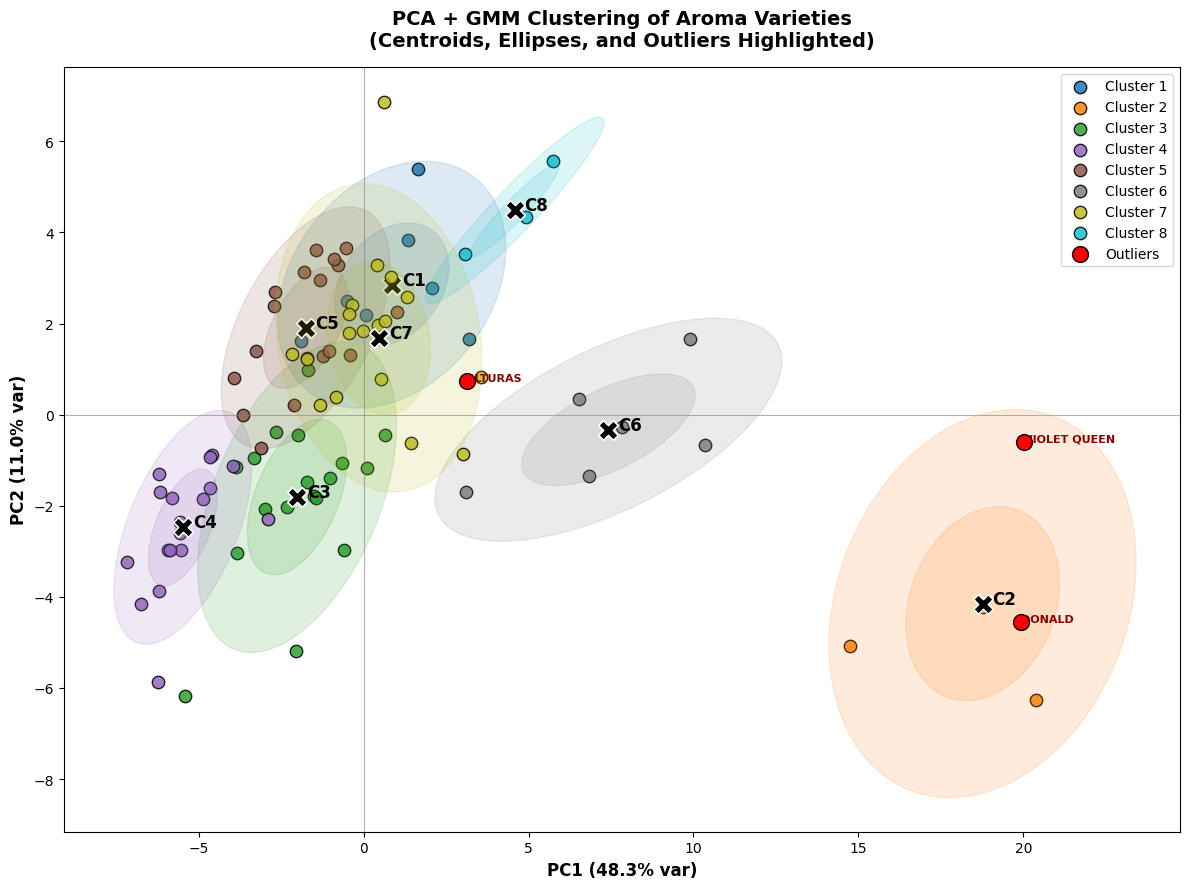

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


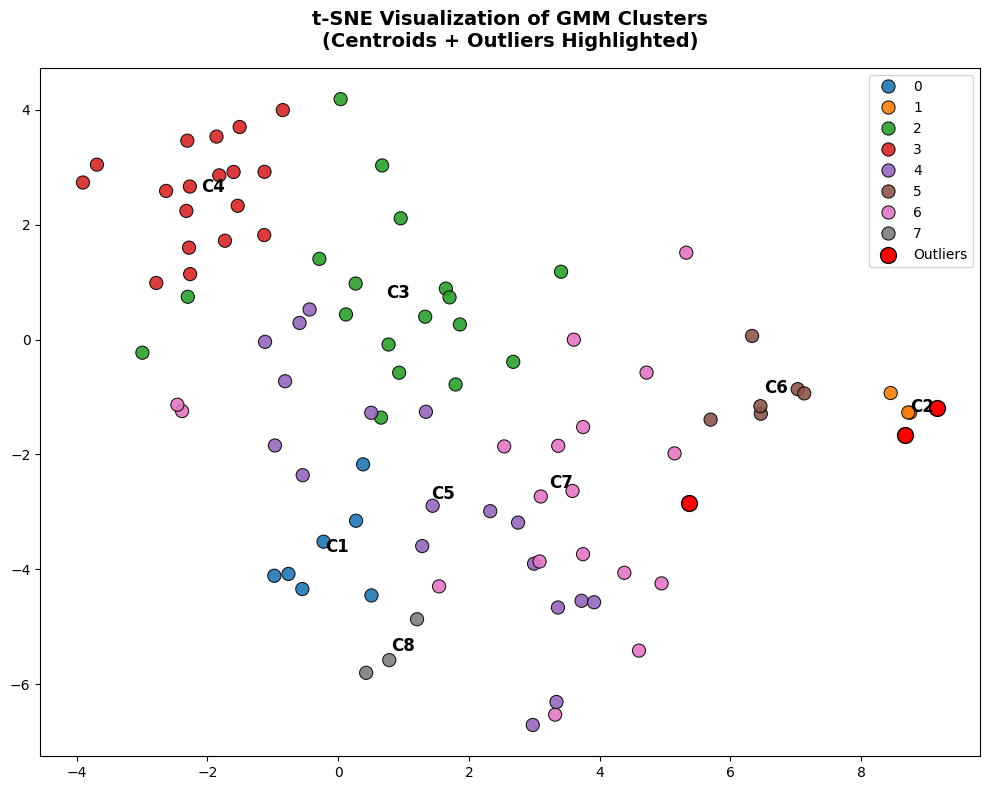


Results saved in: aroma_cluster_results


In [25]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import analyze_aroma_clusters_gmm
# --- Run function ---
results, cluster_means = analyze_aroma_clusters_gmm(paroma_matrix)


# Comparative Analysis of Aroma Compound Classes Between Outlier and Inlier Potato Varieties

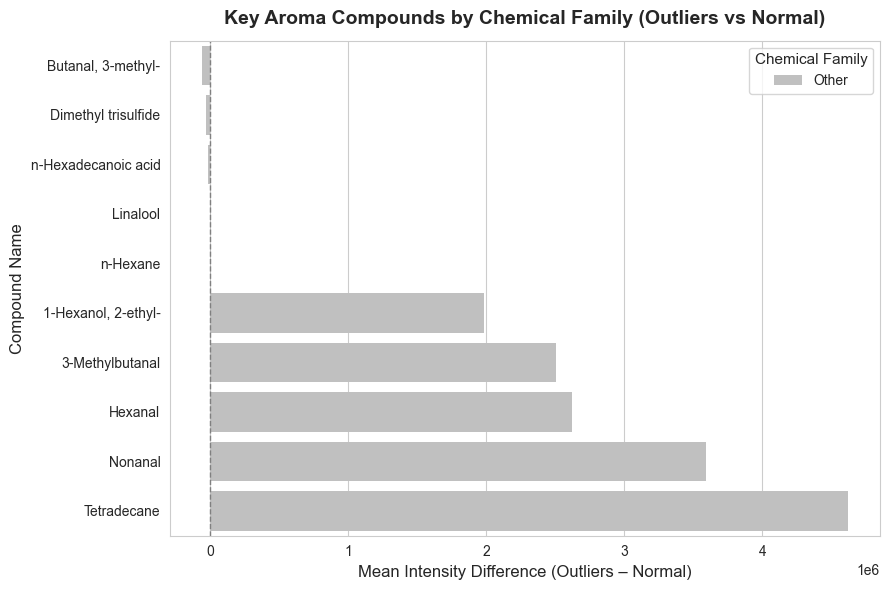

Saved: aroma_cluster_results\outlier_vs_normal_aromas.png


In [26]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_outlier_vs_normal_aromas



top_diff, mean_profiles = plot_outlier_vs_normal_aromas(
    aroma_matrix=paroma_matrix,   # ✅ بهتره ماتریس باشه نه aroma_sample_df
    outliers=['ALTURAS','ANIVIA','DONALD','VIOLET QUEEN'],
    chemical_family_map=None               # یا CHEMICAL_FAMILY_MAP (dict)
)



#  Major Contributing Aroma Compounds (Mean Intensity-Based Ranking)


 Total compounds analyzed: 67
 Top 10 aroma compounds by average intensity:

                                   mean         std
Compound Name                                      
Nonanal                     15407718.84  5116314.32
2-Propanone, 1-methoxy-      9465662.37  3665132.13
Decanal                      5025552.89  1928526.89
3-Methylbutanal              3341821.75  2037461.18
Tetradecane                  2796984.30  2488367.26
Acetic acid, ethenyl ester   2569187.60   842315.08
2,3-Butanedione              2569187.60   842315.08
Dimethyl disulfide           2256378.92  1031789.75
Hexanal                      2178696.46  1520145.67
n-Hexadecanoic acid          2044767.56  1308776.44


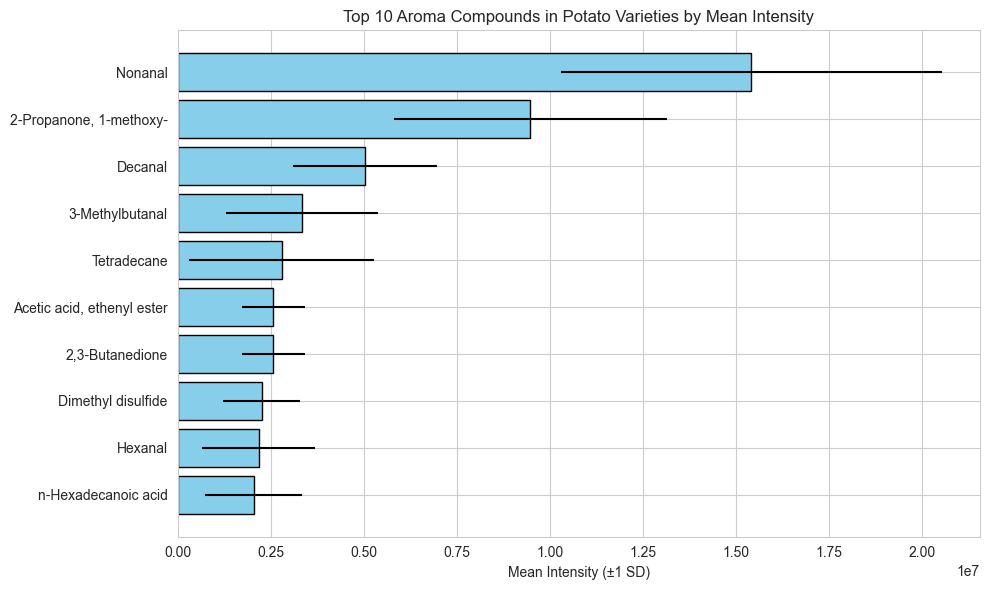

In [27]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_aroma_intensities

desc_stats, top_compounds = summarize_aroma_intensities(paroma_matrix, top_n=10)

# Heatmap of Top Aroma Compounds in Potato Varieties

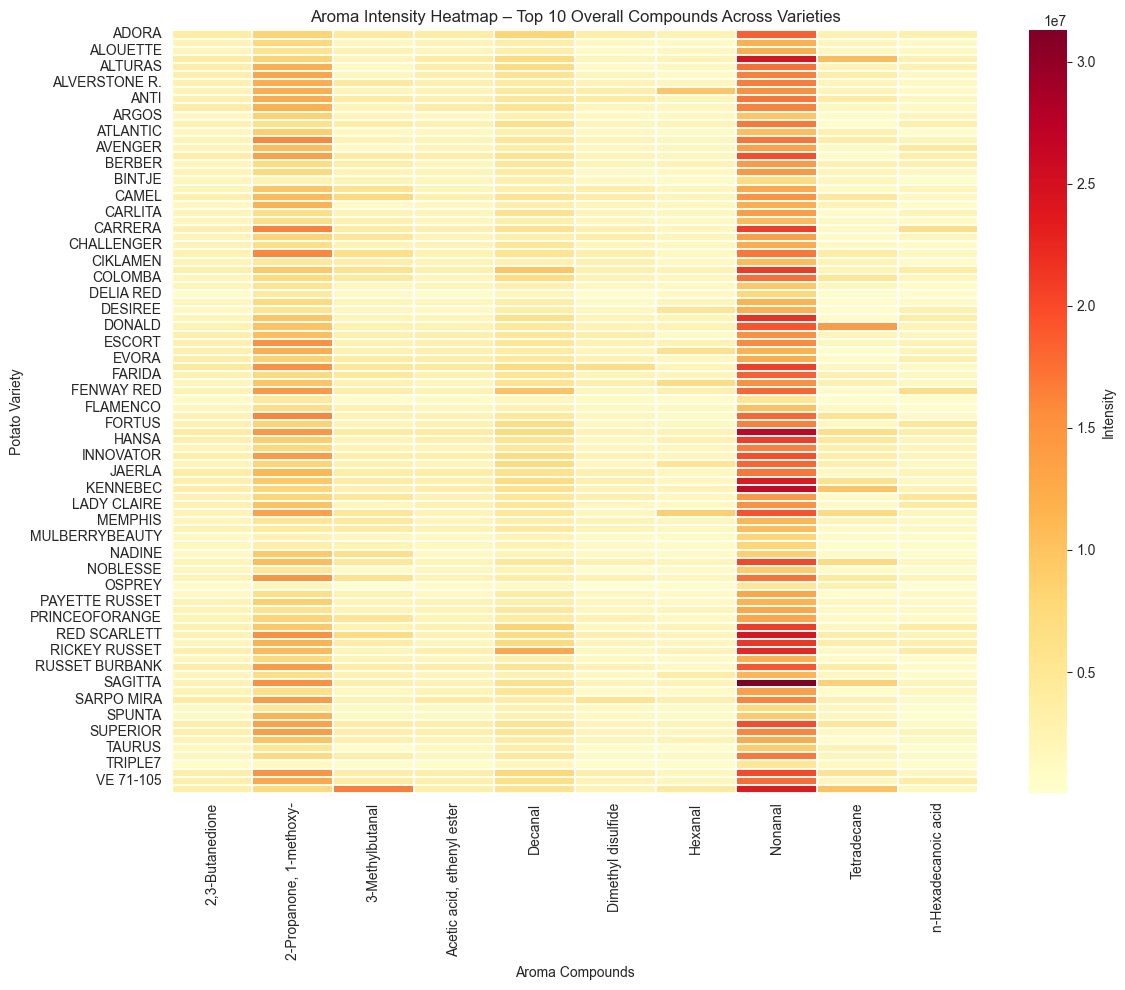

Compound,"2,3-Butanedione","2-Propanone, 1-methoxy-",3-Methylbutanal,"Acetic acid, ethenyl ester",Decanal,Dimethyl disulfide,Hexanal,Nonanal,Tetradecane,n-Hexadecanoic acid
Variety,,,,,,,,,,
ADORA,3.878951e+06,8.268075e+06,4.342225e+06,3.878951e+06,8.188419e+06,3.500004e+06,2.714153e+06,1.850711e+07,2.913931e+06,3.194588e+06
AGRIA,2.378290e+06,7.889641e+06,1.673090e+06,2.378290e+06,3.616735e+06,1.516528e+06,1.256580e+06,1.197010e+07,1.906090e+06,1.238362e+06
ALOUETTE,2.148962e+06,5.672552e+06,2.759678e+06,2.148962e+06,3.600695e+06,1.247146e+06,1.532335e+06,1.221545e+07,1.599592e+06,1.318677e+06
ALTHEA,4.107482e+06,8.452348e+06,2.073696e+06,4.107482e+06,7.402744e+06,2.016362e+06,2.588335e+06,2.439253e+07,1.074566e+07,2.941198e+06
ALTURAS,3.593850e+06,1.222093e+07,1.495736e+06,3.593850e+06,7.030008e+06,1.051794e+06,1.580432e+06,1.760424e+07,2.454429e+06,2.884708e+06
...,...,...,...,...,...,...,...,...,...,...
TETON RUSSET,1.932632e+06,7.386411e+06,3.588553e+06,1.932632e+06,4.836277e+06,1.268935e+06,1.288572e+06,1.695253e+07,2.116594e+06,1.217210e+06
TRIPLE7,9.000865e+05,1.295528e+06,6.471797e+05,9.000865e+05,1.660857e+06,6.928501e+05,6.211116e+05,5.048898e+06,1.350161e+06,5.676972e+05
VAN GOGH,3.546951e+06,1.485115e+07,3.898049e+06,3.546951e+06,7.861392e+06,3.522898e+06,1.912771e+06,1.996757e+07,5.724713e+06,1.646577e+06


In [28]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_top_aroma_heatmap

# Show top 10 compounds overall across varieties
plot_top_aroma_heatmap(paroma_matrix, top_n=10, mode="overall")

# Interactive Aroma Compound Dashboard for Potato Varieties

In [29]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import launch_aroma_dashboard
launch_aroma_dashboard()


TypeError: launch_aroma_dashboard() missing 1 required positional argument: 'aroma_matrix'

# Feature Importance Analysis of Aroma Compounds Using PCA Loadings

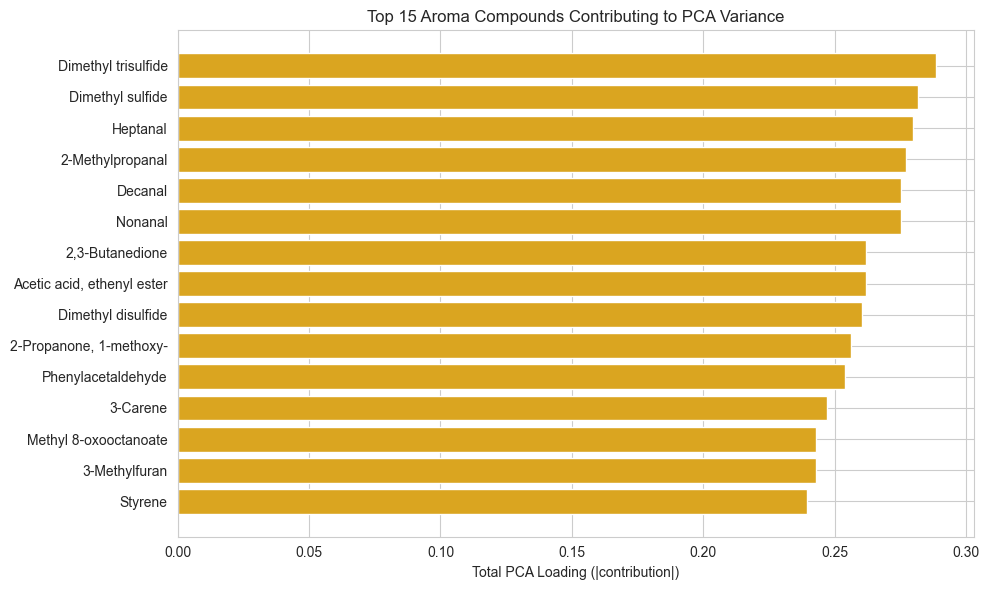

 Top 15 most contributing compounds:
                                 PC1       PC2  Total_Importance
Dimethyl trisulfide         0.034682  0.253675          0.288358
Dimethyl sulfide            0.047056  0.234508          0.281565
Heptanal                    0.096975  0.182589          0.279564
2-Methylpropanal            0.048674  0.228415          0.277088
Decanal                     0.065356  0.209676          0.275032
Nonanal                     0.105263  0.169739          0.275003
2,3-Butanedione             0.072705  0.189339          0.262045
Acetic acid, ethenyl ester  0.072705  0.189339          0.262045
Dimethyl disulfide          0.032195  0.228032          0.260227
2-Propanone, 1-methoxy-     0.041354  0.214694          0.256049
Phenylacetaldehyde          0.087463  0.166590          0.254053
3-Carene                    0.048476  0.198592          0.247068
Methyl 8-oxooctanoate       0.125775  0.117009          0.242784
3-Methylfuran               0.040442  0.202303       

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import compute_feature_importance_from_pca
importance_df = compute_feature_importance_from_pca(aroma_sample_df)


# Joining the sensory panel data 

In [ ]:

# --- Load configuration ---
with open(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Read the sensory Excel file using config path ---
sensory_path = config["paths"]["sensory_data"]
sensory = pd.read_excel(sensory_path)

# --- Print column names and preview the first few rows ---
print("Columns:", list(sensory.columns))
display(sensory.head(config["settings"]["display_rows"]))


Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, clus

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Sensory Panel Data Processing

In [ ]:

import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_sensory_traits

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = summarize_sensory_traits(sensory, sensory_cols)

 Rows (unique varieties): 59
 Traits averaged: 20

 Example of summarized sensory data:
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  ...  Sweet Aftertaste  \
0          

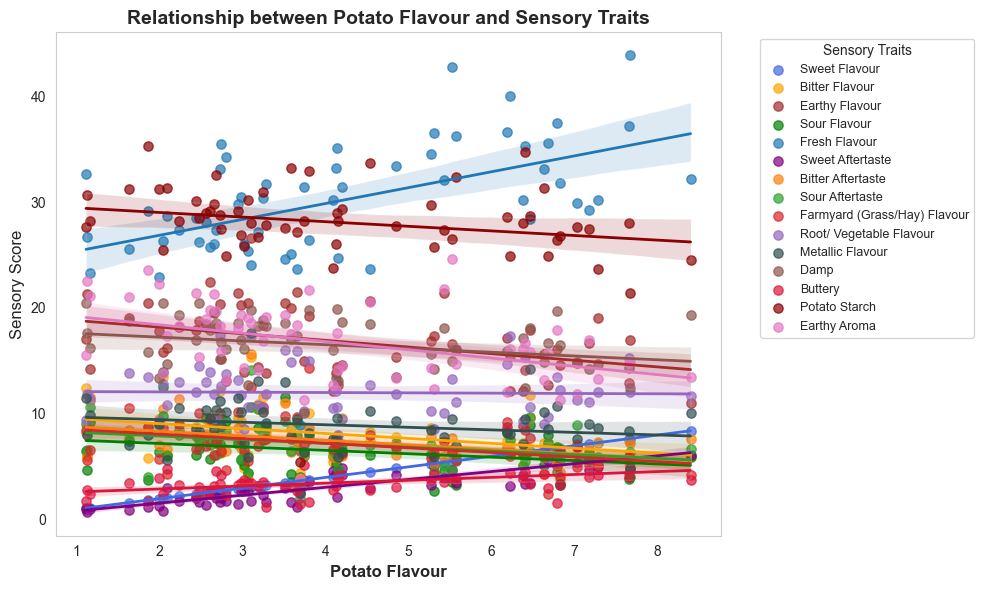

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_sensory_vs_flavour

plot_sensory_vs_flavour(sensory_summary, base_trait="SWEET FLAVOUR")


# Predicting the flavors for all the non existing varaieties by using the aroma compounds

# First merge aroma and sensory datasets

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import merge_aroma_with_sensory


merged_aroma_sensory, common = merge_aroma_with_sensory(aroma_sample_df, sensory_summary)



Varieties in Aroma Data   : 94
Varieties in Sensory Data : 59
Common varieties          : 20
Merged varieties          : 20
Merged shape              : (20, 116)


,Variety,(E)-2-Decenal,(E)-2-Heptenal,(E)-2-Hexenal,"(E, E)-2,4-Decadienal","1,2-dimethoxy-Benzene",1-Heptanol,"1-Hexanol, 2-ethyl-",1-Nonanol,1-Octen-3-ol,...,Sweet Aftertaste,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Potato Starch,Metalic
0,ADORA,158950.924928,137333.382895,23029.325439,128292.973358,265325.942398,122864.514862,1.282840e+06,74974.316997,111570.271948,...,1.790,18.537,15.953,4.385,21.588,19.845,3.491,29.071,28.018,16.498
1,AGRIA,75482.858841,73198.432709,10921.114662,56698.907947,292049.966730,76163.422235,6.200850e+05,62564.190846,37125.062178,...,1.203,23.580,12.801,3.298,23.219,15.823,1.752,26.592,35.300,9.280
2,BERBER,169470.820105,114340.671498,17699.164973,181974.730600,343934.274301,102455.637368,5.659599e+05,72561.501604,75382.554730,...,3.355,16.732,10.866,7.146,24.719,12.410,4.535,31.505,34.713,7.520
3,BILDTSTAR,103405.517301,80954.949624,16151.472538,136732.059749,327854.522244,112422.856892,1.346371e+06,86086.006430,69377.849116,...,0.756,22.512,16.668,2.590,21.487,17.625,2.791,24.566,30.645,7.869
4,BINTJE,52117.517670,57936.159158,13069.628723,55368.373913,171607.799193,106963.805644,2.953530e+05,31196.086168,20156.114175,...,3.506,14.671,10.804,7.408,19.260,16.103,3.859,29.521,32.350,6.301


Found 95 aroma compounds and 20 sensory traits.
Displaying 95 compounds (threshold=0.2).


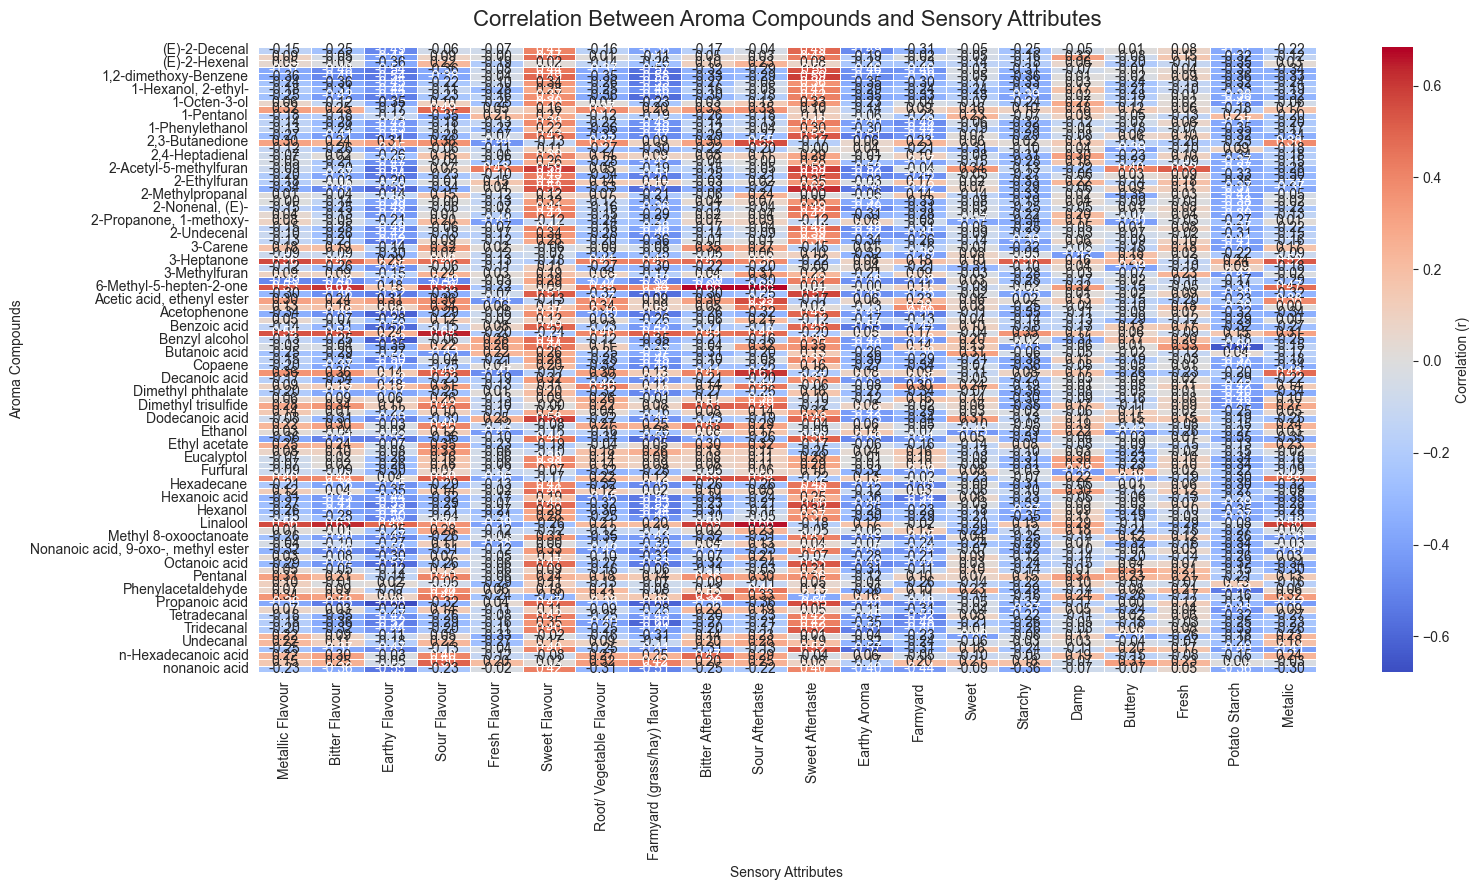

Correlation matrix saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/aroma_sensory_corr_output.csv


In [ ]:
import yaml
import importlib
import compound_analysis_module
from compound_analysis_module import plot_aroma_sensory_correlation

# Reload if working interactively
importlib.reload(compound_analysis_module)

# --- Load config ---
with open(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\config.yaml",
    "r"
) as f:
    config = yaml.safe_load(f)

# --- Define sensory columns (still explicit; they stay the same) ---
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
    "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
    "Damp","Buttery","Fresh","Potato Starch","Metalic"
]

corr_result = plot_aroma_sensory_correlation(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=sensory_cols,
    aroma_descriptions=None,  
    threshold=config["settings"]["correlation_threshold"],
    min_compounds=config["settings"]["min_compounds"],
    save_path=config["paths"]["aroma_sensory_corr_output"]
)



# Sensory prediction based on aroma compounds using multiple models.

# PLSR MOdel + MAF score

['Variety', '(E)-2-Decenal', '(E)-2-Heptenal', '(E)-2-Hexenal', '(E, E)-2,4-Decadienal', '1,2-dimethoxy-Benzene', '1-Heptanol', '1-Hexanol, 2-ethyl-', '1-Nonanol', '1-Octen-3-ol', '1-Octyn-3-ol', '1-Pentanol', '1-Penten-3-one', '1-Phenylethanol', '2(3H)-Furanone, dihydro-5-pentyl-', '2,3-Butanedione', '2,3-Pentanedione', '2,4-Heptadienal', '2,4-Nonadienal', '2-Acetyl-5-methylfuran', '2-Decanone', '2-Ethylfuran', '2-Heptanone', '2-Methylpropanal', '2-Nonanone', '2-Nonenal, (E)-', '2-Octenal, (E)-', '2-Propanone, 1-methoxy-', '2-Tridecenal', '2-Undecenal', '3,5-Octadien-2-one', '3-Carene', '3-Furaldehyde', '3-Heptanone', '3-Heptanone, 4-methyl-', '3-Methylfuran', '3-Octanone', '6-Methyl-5-hepten-2-one', 'Acetic acid', 'Acetic acid, ethenyl ester', 'Acetic acid, methyl ester', 'Acetophenone', 'Benzaldehyde', 'Benzoic acid', 'Benzoic acid, methyl ester', 'Benzyl alcohol', 'Butanal, 3-methyl-', 'Butanoic acid', 'Butanoic acid, butyl ester', 'Copaene', 'Decanal', 'Decanoic acid', 'Dimethyl d

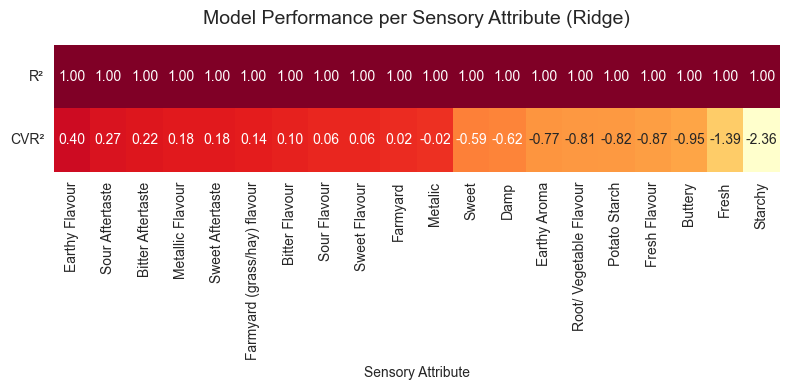

Training with 20 samples, 95 aroma features, and 20 sensory traits.

Fitting model: Linear

Cross-validated performance summary:
               Sensory Attribute   R²      CVR²
2                 Earthy Flavour  1.0  0.404764
9                Sour Aftertaste  1.0  0.256729
8              Bitter Aftertaste  1.0  0.225159
0               Metallic Flavour  1.0  0.200773
10              Sweet Aftertaste  1.0  0.176263
7   Farmyard (grass/hay) flavour  1.0  0.131937
1                 Bitter Flavour  1.0  0.102180
5                  Sweet Flavour  1.0  0.050359
3                   Sour Flavour  1.0  0.033571
12                      Farmyard  1.0  0.015333
19                       Metalic  1.0 -0.026419
13                         Sweet  1.0 -0.619284
15                          Damp  1.0 -0.652321
18                 Potato Starch  1.0 -0.886604
6        Root/ Vegetable Flavour  1.0 -0.901415
4                  Fresh Flavour  1.0 -0.920195
11                  Earthy Aroma  1.0 -0.932508
16     

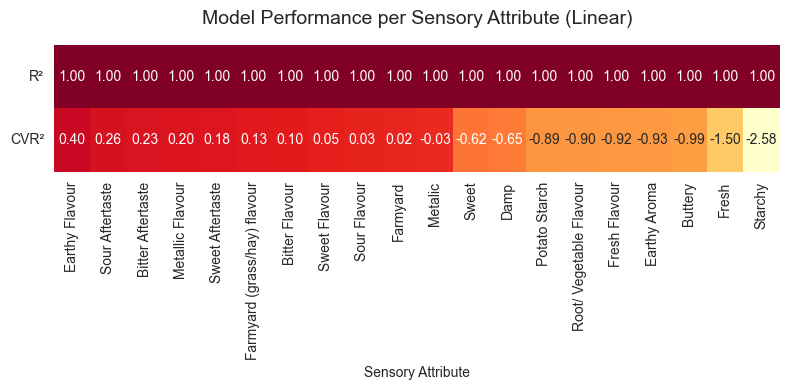

Training with 20 samples, 95 aroma features, and 20 sensory traits.

Fitting model: ElasticNet

Cross-validated performance summary:
               Sensory Attribute        R²      CVR²
2                 Earthy Flavour  0.554060  0.158171
3                   Sour Flavour  0.546404  0.128090
1                 Bitter Flavour  0.655264  0.066523
7   Farmyard (grass/hay) flavour  0.513340  0.056651
10              Sweet Aftertaste  0.448185  0.051490
18                 Potato Starch  0.373255  0.045725
9                Sour Aftertaste  0.611797  0.026453
8              Bitter Aftertaste  0.578452  0.020847
11                  Earthy Aroma  0.356849 -0.016344
5                  Sweet Flavour  0.454538 -0.026505
0               Metallic Flavour  0.525877 -0.053920
19                       Metalic  0.495180 -0.074731
4                  Fresh Flavour  0.342525 -0.083936
14                       Starchy  0.277972 -0.167750
12                      Farmyard  0.300645 -0.176990
17                 

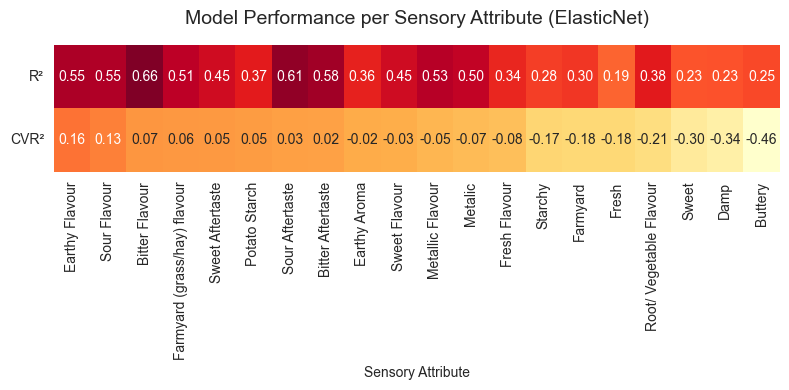

Training with 20 samples, 95 aroma features, and 20 sensory traits.

Fitting model: PLSR

Cross-validated performance summary:
               Sensory Attribute        R²      CVR²
3                   Sour Flavour  0.668801  0.281413
9                Sour Aftertaste  0.667285  0.152666
8              Bitter Aftertaste  0.783136  0.009212
1                 Bitter Flavour  0.774184 -0.013130
7   Farmyard (grass/hay) flavour  0.634012 -0.032776
12                      Farmyard  0.265285 -0.041648
2                 Earthy Flavour  0.680643 -0.057210
10              Sweet Aftertaste  0.435182 -0.111681
19                       Metalic  0.673403 -0.157734
5                  Sweet Flavour  0.445973 -0.170692
11                  Earthy Aroma  0.396756 -0.193221
18                 Potato Starch  0.360399 -0.260744
16                       Buttery  0.072728 -0.280058
14                       Starchy  0.319937 -0.292316
6        Root/ Vegetable Flavour  0.362655 -0.297880
0               Metallic 

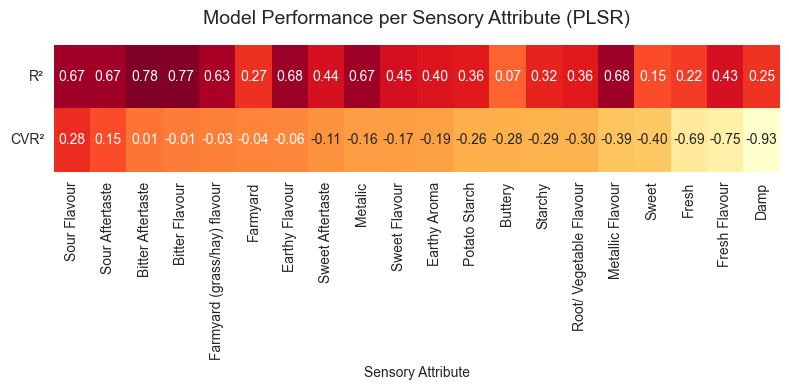

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import predict_sensory_from_models

print(merged_aroma_sensory.columns.tolist())

predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_sample_df,
    sensory_cols=sensory_cols,
    model_type="Ridge",  # Try: 'Linear', 'Lasso', 'ElasticNet', or 'PLSR'
    n_components=3,
    cv_folds=5,
    alpha=0.5
)
predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_sample_df,
    sensory_cols=sensory_cols,
    model_type='Linear',  # Try: 'Linear', 'Lasso', 'ElasticNet', or 'PLSR'
    n_components=3,
    cv_folds=5,
    alpha=0.5
)


predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_sample_df,
    sensory_cols=sensory_cols,
    model_type='ElasticNet', 
    n_components=3,
    cv_folds=5,
    alpha=0.5
)



predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_sample_df,
    sensory_cols=sensory_cols,
    model_type='PLSR',  
    n_components=3,
    cv_folds=5,
    alpha=0.5
)


# Non linear model 


Model Performance Summary (R² and CVR²):
                    metallic flavour  bitter flavour  earthy flavour  \
R²   Random Forest              0.84            0.87            0.87   
     Extra Trees                1.00            1.00            1.00   
     XGBoost                    1.00            1.00            1.00   
     SVR (RBF)                  0.63            0.65            0.72   
CVR² Random Forest             -0.18           -0.08            0.04   
     Extra Trees               -0.18            0.02           -0.09   
     XGBoost                   -0.49           -0.03           -0.03   
     SVR (RBF)                  0.02            0.05           -0.07   

                    sour flavour  fresh flavour  sweet flavour  \
R²   Random Forest          0.86           0.89           0.86   
     Extra Trees            1.00           1.00           1.00   
     XGBoost                1.00           1.00           1.00   
     SVR (RBF)              0.79           0.

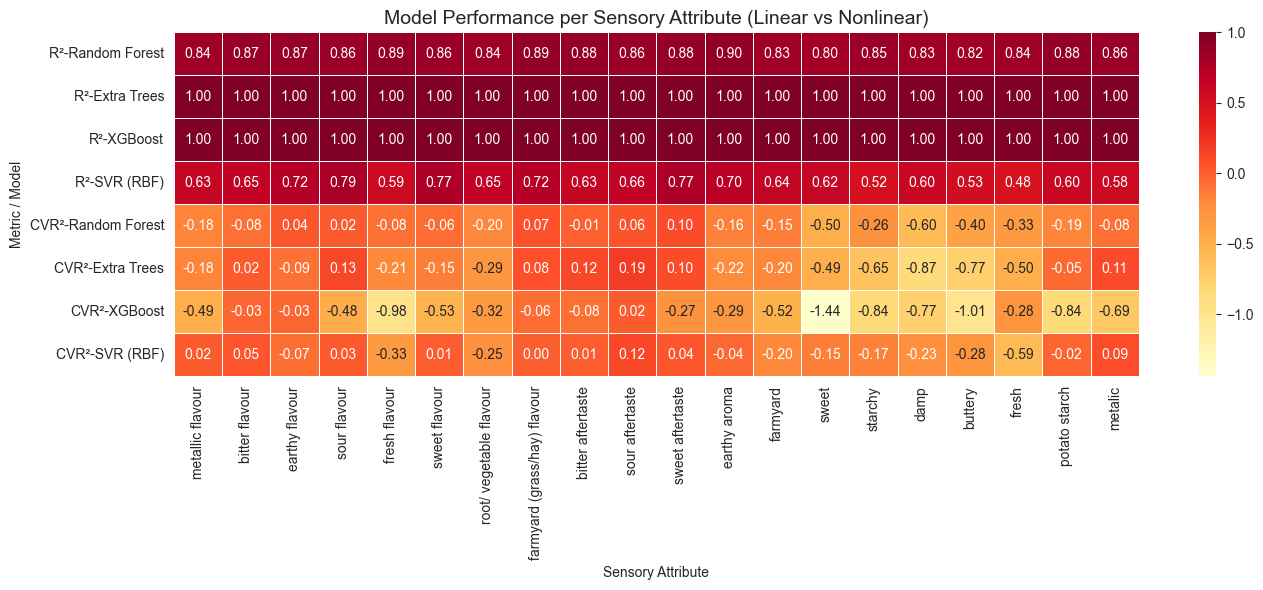

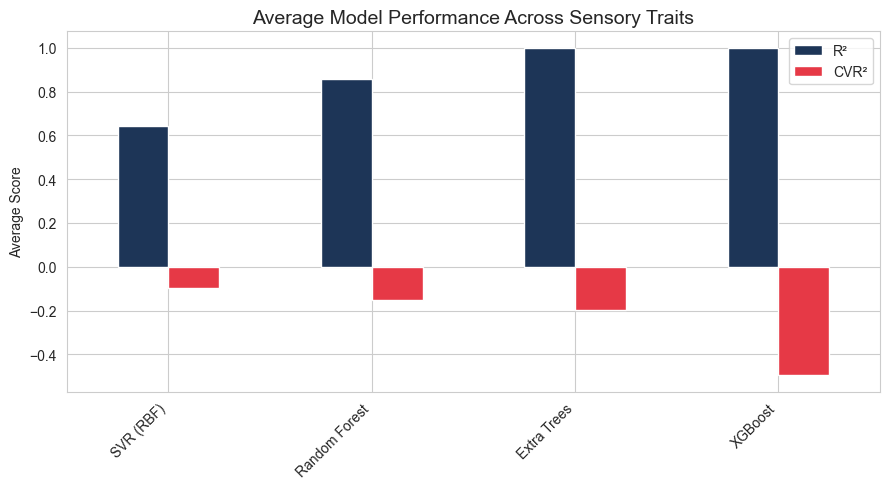

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import  predict_sensory_with_models_and_cvr2

r2_df, cvr2_df, summary = predict_sensory_with_models_and_cvr2(
    merged_aroma_sensory=merged_aroma_sensory,
    aroma_matrix=aroma_sample_df,
    sensory_cols=sensory_cols,
    n_estimators=300,     # number of trees for RF / ExtraTrees
    n_components=3,       # number of latent components for PLSR
    cv_folds=5            # 5-fold cross validation
)



# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA

Varieties total (aroma): 94
Panel varieties (sensory present): 20
Non-panel varieties (sensory missing): 74

PCA explained variance ratio: [0.449 0.194 0.089]
Total projected varieties: 94


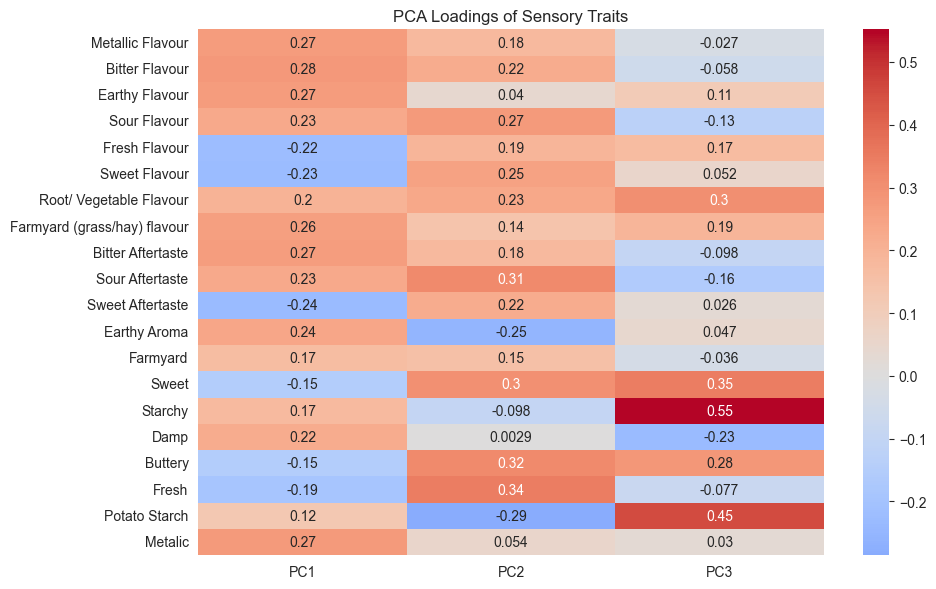

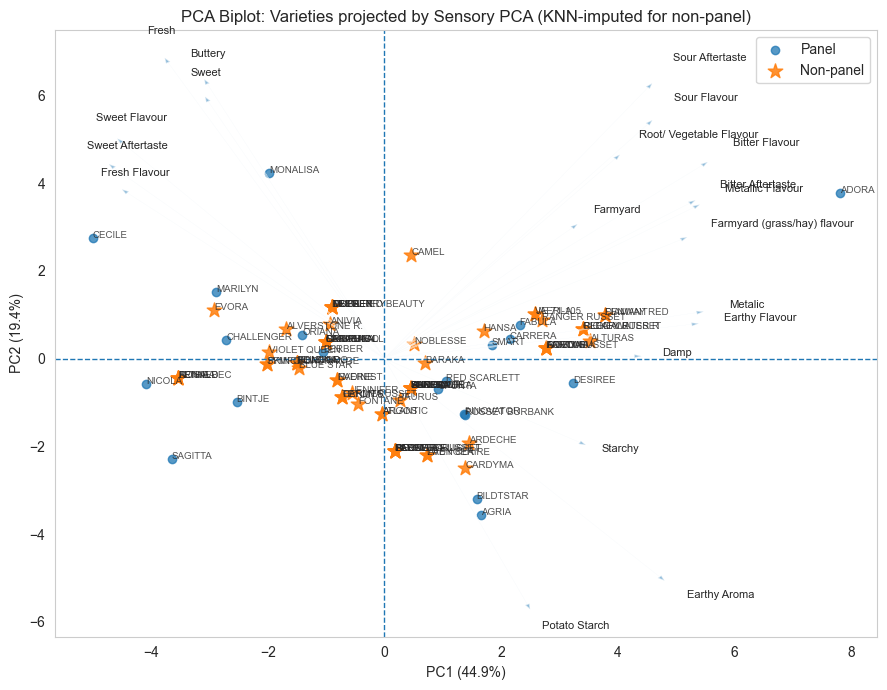

Projection saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/sensory_pca_projection_knn.csv
Loadings saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_loadings.csv
Files saved:
- C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/sensory_pca_projection_knn.csv
- C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_loadings.csv
- C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/pc_df.csv


In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import perform_knn_sensory_projection


# --- Load config ---
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Access paths from config ---
projection_path = config["paths"]["sensory_pca_projection_knn"]
loadings_path = config["paths"]["sensory_pca_loadings"]
pc_df_path = config["paths"]["sensory_pca_pc_df"]

# --- Run the function using paths from config ---
pc_df, pca, loadings_df = perform_knn_sensory_projection(
    aroma_matrix=aroma_sample_df,      # همون ماتریس 94×95 با index=Variety هم اوکیه
    sensory_summary=sensory_summary,   # دیتای پنل
    k=3,
    n_components=3,
    scaling_factor=20,
    save_projection_path=projection_path,
    save_loadings_path=loadings_path
)

pc_df.to_csv(pc_df_path, index=False)
print(f"Files saved:\n- {projection_path}\n- {loadings_path}\n- {pc_df_path}")



In [ ]:

import importlib
import yaml
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import perform_knn_sensory_projection_rotatable_3D

# --- Load YAML configuration ---
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Extract values ---
paths = config["paths"]
params = config["parameters"]

# --- Run the 3D projection function using config values ---
pc_df, pca_model, loadings_df = perform_knn_sensory_projection_rotatable_3D(
    aroma_matrix=aroma_sample_df,
    sensory_summary=sensory_summary,
    rotation_angle_12=params["rotation_angle_12"],
    rotation_angle_13=params["rotation_angle_13"],
    rotation_angle_23=params["rotation_angle_23"],
    scaling_factor=params["scaling_factor"],
    loading_threshold=params["loading_threshold"],
    save_projection_path=paths["sensory_pca_projection"],
    save_loadings_path=paths["sensory_pca_loadings"]
)

#confirm and save dataframe 
pc_df.to_csv(paths["sensory_pca_projection"], index=False)
loadings_df.to_csv(paths["sensory_pca_loadings"], index=False)

print(" Projection and loadings saved:")
print(f"• Projection → {paths['sensory_pca_projection']}")
print(f"• Loadings   → {paths['sensory_pca_loadings']}")


KeyError: 'rotation_angle_12'

# PCA-Based Sensory Profile Summary of Potato Varieties

In [ ]:
# import importlib
# import yaml
# import compound_analysis_module
# importlib.reload(compound_analysis_module)
# from compound_analysis_module import interpret_variety_sensory_profile

# # --- Load from config ---
# with open("config.yaml", "r") as f:
#     config = yaml.safe_load(f)

# interp_cfg = config["interpretation"]

# # --- Run function using config values ---
# summary_df = interpret_variety_sensory_profile(
#     pc_df=pc_df,
#     pc1_thresh=interp_cfg["pc1_thresh"],
#     pc2_thresh=interp_cfg["pc2_thresh"],
#     save_path=interp_cfg["save_path"]
# )

# print(" Variety sensory summary saved to:")
# print(interp_cfg["save_path"])


ImportError: cannot import name 'interpret_variety_sensory_profile' from 'compound_analysis_module' (c:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\analysis with mz\compound_analysis_module.py)

In [ ]:
# def perform_knn_sensory_projection_rotatable(
#     aroma_matrix,
#     sensory_summary,
#     k=3,
#     n_components=3,
#     scaling_factor=4,
#     loading_threshold=0.2,
#     rotation_angle_12=0,     # rotation for PC1–PC2
#     rotation_angle_13=0,     # rotation for PC1–PC3
#     save_projection_path=None,
#     save_loadings_path=None
# ):
#     """
#     Merge aroma + sensory data, impute missing sensory traits using KNN,
#     perform PCA on sensory traits, visualize projection (PC1–PC2 and PC1–PC3)
#     with independent rotation controls, loadings heatmap, and biplots.
#     """

#     # --- Step 1: Standardize column names ---
#     aroma_matrix = aroma_matrix.copy()
#     sensory_summary = sensory_summary.copy()
#     aroma_matrix.columns = aroma_matrix.columns.str.strip().str.upper()
#     sensory_summary.columns = sensory_summary.columns.str.strip().str.upper()

#     # --- Step 2: Check for Variety column ---
#     if "VARIETY" not in aroma_matrix.columns:
#         raise KeyError("'VARIETY' column not found in aroma_matrix!")
#     if "VARIETY" not in sensory_summary.columns:
#         raise KeyError("'VARIETY' column not found in sensory_summary!")

#     # --- Step 3: Merge datasets ---
#     merged = aroma_matrix.merge(sensory_summary, on="VARIETY", how="left")
#     merged["IS_PANEL"] = merged["VARIETY"].isin(sensory_summary["VARIETY"])

#     panel_df = merged[merged["IS_PANEL"]].reset_index(drop=True)
#     nonpanel_df = merged[~merged["IS_PANEL"]].reset_index(drop=True)

#     sensory_cols = [c for c in sensory_summary.columns if c != "VARIETY"]
#     aroma_cols = [c for c in aroma_matrix.columns if c != "VARIETY"]

#     Y_panel = panel_df[sensory_cols].fillna(0)
#     X_panel = panel_df[aroma_cols].fillna(0)
#     X_nonpanel = nonpanel_df[aroma_cols].fillna(0)

#     # --- Step 4: KNN imputation ---
#     nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
#     nn.fit(X_panel)
#     distances, indices = nn.kneighbors(X_nonpanel)
#     Y_nonpanel_pred = np.array([Y_panel.iloc[idx].mean(axis=0) for idx in indices])

#     # --- Step 5: PCA ---
#     scaler = StandardScaler().fit(Y_panel.values)
#     X_panel_scaled = scaler.transform(Y_panel.values)
#     X_nonpanel_scaled = scaler.transform(Y_nonpanel_pred)

#     pca = PCA(n_components=n_components, random_state=0)
#     pcs_panel = pca.fit_transform(X_panel_scaled)
#     pcs_nonpanel = pca.transform(X_nonpanel_scaled)

#     panel_pcs = pd.DataFrame(pcs_panel, columns=[f"PC{i+1}" for i in range(n_components)])
#     panel_pcs["Variety"] = panel_df["VARIETY"].values
#     panel_pcs["is_panel"] = True

#     nonpanel_pcs = pd.DataFrame(pcs_nonpanel, columns=[f"PC{i+1}" for i in range(n_components)])
#     nonpanel_pcs["Variety"] = nonpanel_df["VARIETY"].values
#     nonpanel_pcs["is_panel"] = False

#     pc_df = pd.concat([panel_pcs, nonpanel_pcs], ignore_index=True)

#     loadings_df = pd.DataFrame(
#         pca.components_.T,
#         columns=[f"PC{i+1}" for i in range(n_components)],
#         index=sensory_cols
#     )

#     print("\nPCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

#     # --- Step 6: Separate rotations ---
#     theta12 = np.deg2rad(rotation_angle_12)
#     theta13 = np.deg2rad(rotation_angle_13)

#     rot12 = np.array([[np.cos(theta12), -np.sin(theta12)],
#                       [np.sin(theta12),  np.cos(theta12)]])
#     rot13 = np.array([[np.cos(theta13), -np.sin(theta13)],
#                       [np.sin(theta13),  np.cos(theta13)]])

#     rotated_scores_12 = pc_df[["PC1", "PC2"]].values @ rot12
#     rotated_loadings_12 = loadings_df[["PC1", "PC2"]].values @ rot12
#     pc_df["PC1_rot12"], pc_df["PC2_rot12"] = rotated_scores_12[:, 0], rotated_scores_12[:, 1]
#     loadings_df["PC1_rot12"], loadings_df["PC2_rot12"] = rotated_loadings_12[:, 0], rotated_loadings_12[:, 1]

#     rotated_scores_13 = pc_df[["PC1", "PC3"]].values @ rot13
#     rotated_loadings_13 = loadings_df[["PC1", "PC3"]].values @ rot13
#     pc_df["PC1_rot13"], pc_df["PC3_rot13"] = rotated_scores_13[:, 0], rotated_scores_13[:, 1]
#     loadings_df["PC1_rot13"], loadings_df["PC3_rot13"] = rotated_loadings_13[:, 0], rotated_loadings_13[:, 1]

#     # --- Step 7: Loadings heatmap ---
#     plt.figure(figsize=(10, 6))
#     sns.heatmap(loadings_df[["PC1", "PC2", "PC3"]], annot=True, cmap="coolwarm", center=0)
#     plt.title("PCA Loadings of Sensory Traits (Before Rotation)")
#     plt.grid(False)
#     plt.tight_layout()
#     plt.show()

#     # --- Step 8: Rotated PC1–PC2 Biplot (no gridlines) ---
#     plt.figure(figsize=(8, 7))
#     plt.scatter(pc_df.loc[pc_df["is_panel"], "PC1_rot12"],
#                 pc_df.loc[pc_df["is_panel"], "PC2_rot12"],
#                 c="blue", label="Panel", alpha=0.7)
#     plt.scatter(pc_df.loc[~pc_df["is_panel"], "PC1_rot12"],
#                 pc_df.loc[~pc_df["is_panel"], "PC2_rot12"],
#                 c="orange", marker="*", s=120, label="Non-panel")

#     for i, row in pc_df.iterrows():
#         if row["is_panel"]:
#             plt.text(row["PC1_rot12"], row["PC2_rot12"], row["Variety"], fontsize=7)

#     strong_features_12 = loadings_df[
#         (loadings_df["PC1"].abs() > loading_threshold) |
#         (loadings_df["PC2"].abs() > loading_threshold)
#     ]

#     for feature in strong_features_12.index:
#         x = loadings_df.loc[feature, "PC1_rot12"] * scaling_factor
#         y = loadings_df.loc[feature, "PC2_rot12"] * scaling_factor
#         plt.arrow(0, 0, x, y, color="red", alpha=0.6, head_width=0.08, length_includes_head=True)
#         plt.text(x * 1.1, y * 1.1, feature, color="red", fontsize=8)

#     plt.xlabel("Rotated PC1 (PC1–PC2 plane)")
#     plt.ylabel("Rotated PC2")
#     plt.title(f"PCA Biplot (Rotated {rotation_angle_12}° — PC1 vs PC2)")
#     plt.legend()
#     plt.grid(False)
#     plt.tight_layout()
#     plt.show()

#     # --- Step 9: Rotated PC1–PC3 Biplot (no gridlines) ---
#     plt.figure(figsize=(8, 7))
#     plt.scatter(pc_df.loc[pc_df["is_panel"], "PC1_rot13"],
#                 pc_df.loc[pc_df["is_panel"], "PC3_rot13"],
#                 c="blue", label="Panel", alpha=0.7)
#     plt.scatter(pc_df.loc[~pc_df["is_panel"], "PC1_rot13"],
#                 pc_df.loc[~pc_df["is_panel"], "PC3_rot13"],
#                 c="orange", marker="*", s=120, label="Non-panel")

#     for i, row in pc_df.iterrows():
#         if row["is_panel"]:
#             plt.text(row["PC1_rot13"], row["PC3_rot13"], row["Variety"], fontsize=7)

#     strong_features_13 = loadings_df[
#         (loadings_df["PC1"].abs() > loading_threshold) |
#         (loadings_df["PC3"].abs() > loading_threshold)
#     ]

#     for feature in strong_features_13.index:
#         x = loadings_df.loc[feature, "PC1_rot13"] * scaling_factor
#         y = loadings_df.loc[feature, "PC3_rot13"] * scaling_factor
#         plt.arrow(0, 0, x, y, color="red", alpha=0.6, head_width=0.08, length_includes_head=True)
#         plt.text(x * 1.1, y * 1.1, feature, color="red", fontsize=8)

#     plt.xlabel("Rotated PC1 (PC1–PC3 plane)")
#     plt.ylabel("Rotated PC3")
#     plt.title(f"PCA Biplot (Rotated {rotation_angle_13}° — PC1 vs PC3)")
#     plt.legend()
#     plt.grid(False)
#     plt.tight_layout()
#     plt.show()

#     return pc_df, pca, loadings_df

# pc_df, pca_model, loadings_df = perform_knn_sensory_projection_rotatable(
#     aroma_matrix=aroma_matrix,
#     sensory_summary=sensory_summary,
#     rotation_angle_12=0,   # rotate PC1–PC2 plane 30°
#     rotation_angle_13=0,  # rotate PC1–PC3 plane 180°
#     scaling_factor=15,
#     loading_threshold=0.2
# )


# Sensory pcs interpretation

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import interpret_variety_sensory
# Generate the interpretation table
sensory_profile_table = interpret_variety_sensory(pc_df, loadings_df)
display(sensory_profile_table.head(10))


,Variety,Dominant traits (PC1),Dominant traits (PC2),Dominant traits (PC3)
0,ADORA,"Bitter Flavour, Metalic, Metallic Flavour","Fresh, Buttery, Sour Aftertaste","low Starchy, low Potato Starch, low Sweet"
1,AGRIA,"Bitter Flavour, Metalic, Metallic Flavour","low Fresh, low Buttery, low Sour Aftertaste","Starchy, Potato Starch, Sweet"
2,BERBER,"low Bitter Flavour, low Metalic, low Metallic ...","Fresh, Buttery, Sour Aftertaste","Starchy, Potato Starch, Sweet"
3,BILDTSTAR,"Bitter Flavour, Metalic, Metallic Flavour","low Fresh, low Buttery, low Sour Aftertaste","Starchy, Potato Starch, Sweet"
4,BINTJE,"low Bitter Flavour, low Metalic, low Metallic ...","low Fresh, low Buttery, low Sour Aftertaste","Starchy, Potato Starch, Sweet"
5,CARRERA,"Bitter Flavour, Metalic, Metallic Flavour","Fresh, Buttery, Sour Aftertaste","low Starchy, low Potato Starch, low Sweet"
6,CECILE,"low Bitter Flavour, low Metalic, low Metallic ...","Fresh, Buttery, Sour Aftertaste","low Starchy, low Potato Starch, low Sweet"
7,CHALLENGER,"low Bitter Flavour, low Metalic, low Metallic ...","Fresh, Buttery, Sour Aftertaste","Starchy, Potato Starch, Sweet"
8,DESIREE,"Bitter Flavour, Metalic, Metallic Flavour","low Fresh, low Buttery, low Sour Aftertaste","Starchy, Potato Starch, Sweet"
9,FABULA,"Bitter Flavour, Metalic, Metallic Flavour","Fresh, Buttery, Sour Aftertaste","Starchy, Potato Starch, Sweet"
